##### <font color='orange'>**Graph Representations**</font>

In [1]:
# G = (V, E)
# We can use tuples to represent a graph 

# https://ocw.mit.edu/courses/6-006-introduction-to-algorithms-spring-2020/resources/mit6_006s20_r09/

In [1]:
from collections import namedtuple 

In [2]:
# arg[0]
# arg[1]: names of the components of our graph
Graph = namedtuple("Graph", ["nodes", "edges"])

In [8]:
Graph.__doc__ 

'Graph(nodes, edges)'

In [13]:
Graph.__contains__

<slot wrapper '__contains__' of 'tuple' objects>

__main__.Graph[1]

Not the best representation as it is very inefficient compared to the two that we will introduce.

In [18]:
nodes = ["A", "B", "C", "D"]
edges = [
    ("A", "B"),
    ("A", "B"),
    ("A", "C"),
    ("A", "C"),
    ("A", "D"),
    ("A", "D"),
    ("B", "D"),
    ("C", "D")
]

In [19]:
G = Graph(nodes, edges)

In [20]:
G

Graph(nodes=['A', 'B', 'C', 'D'], edges=[('A', 'B'), ('A', 'B'), ('A', 'C'), ('A', 'C'), ('A', 'D'), ('A', 'D'), ('B', 'D'), ('C', 'D')])

In [21]:
G.nodes

['A', 'B', 'C', 'D']

In [22]:
G.edges

[('A', 'B'),
 ('A', 'B'),
 ('A', 'C'),
 ('A', 'C'),
 ('A', 'D'),
 ('A', 'D'),
 ('B', 'D'),
 ('C', 'D')]

##### <font color='pink'>**Adjacency List**</font>


Below is the adjacency list representation of the Königsberg's graph problem! <br>
A: B, B, C, C, D <br>
B: A, A, D  <br>
C: A, A, D  <br>
D: A, B, C  <br>

In [38]:
def adjacency_dict(graph: Graph):
    """
    Returns the adjacency list representation of given graph 'G'
    """ 
    
    # node has to be hashable (of mutable type).
    # if node is not hashable or it is mutable, then we can run into severe problems
    Adj = {node: [] for node in graph.nodes}
    # input("Enter sth: ")
    print(f"Before: {Adj}")
    # print(Adj)
    for edge in graph.edges:
        node1, node2 = edge[0], edge[1]
        Adj[node1].append(node2)
        Adj[node2].append(node1)
        print(f"After: {Adj}")
        input()
    return Adj 


In [33]:
adjacency_dict(G)

{'A': [], 'B': [], 'C': [], 'D': []}


{'A': ['A', 'A', 'A', 'A', 'A', 'A'],
 'B': ['B', 'B', 'B'],
 'C': ['C', 'C', 'C'],
 'D': ['D', 'D', 'D', 'D']}

In [39]:
adjacency_dict(G)

Before: {'A': [], 'B': [], 'C': [], 'D': []}
After: {'A': ['B'], 'B': ['A'], 'C': [], 'D': []}
After: {'A': ['B', 'B'], 'B': ['A', 'A'], 'C': [], 'D': []}
After: {'A': ['B', 'B', 'C'], 'B': ['A', 'A'], 'C': ['A'], 'D': []}
After: {'A': ['B', 'B', 'C', 'C'], 'B': ['A', 'A'], 'C': ['A', 'A'], 'D': []}
After: {'A': ['B', 'B', 'C', 'C', 'D'], 'B': ['A', 'A'], 'C': ['A', 'A'], 'D': ['A']}
After: {'A': ['B', 'B', 'C', 'C', 'D', 'D'], 'B': ['A', 'A'], 'C': ['A', 'A'], 'D': ['A', 'A']}
After: {'A': ['B', 'B', 'C', 'C', 'D', 'D'], 'B': ['A', 'A', 'D'], 'C': ['A', 'A'], 'D': ['A', 'A', 'B']}
After: {'A': ['B', 'B', 'C', 'C', 'D', 'D'], 'B': ['A', 'A', 'D'], 'C': ['A', 'A', 'D'], 'D': ['A', 'A', 'B', 'C']}


{'A': ['B', 'B', 'C', 'C', 'D', 'D'],
 'B': ['A', 'A', 'D'],
 'C': ['A', 'A', 'D'],
 'D': ['A', 'A', 'B', 'C']}

#### <font color='pink'>Adjacency Matrix</font>

In [40]:
def adjacency_matrix(graph: Graph):
    """
    Returns the adjacency matrix of the graph
    
    Assumes that graph.nodes is equivalent to range(len(graph.nodes): from 0 to V-1)
    """
    adj = [[0 for node in graph.nodes] for node in graph.nodes]
    for edge in graph.edges: 
        node1, node2 = edge[0], edge[1]
        adj[node1][node2] += 1
        adj[node2][node1] += 1
    return adj 
        

In [41]:
adjacency_matrix(G)

TypeError: list indices must be integers or slices, not str

<p>We need to relabel the graph's vertices from type string to type integers. Thus, we can define the following:</p>

In [43]:
nodes = range(4)
edges = [
    # 2 edges between 0 and 1
    (0,1),
    (0,1),
    # 2 edges between 0 and 2 
    (0,2),
    (0,2),
    # 1 edge between 0 and 3 
    (0,3),
    
    # 1 edge between 1 and 3
    (1,3),
    
    # 1 edge between 2 and 3 
    (2,3)
]

In [46]:
G_2 = Graph(nodes, edges)

In [49]:
Adj_mat = adjacency_matrix(G_2)
Adj_mat

[[0, 2, 2, 1], [2, 0, 0, 1], [2, 0, 0, 1], [1, 1, 1, 0]]

[(0, 1), (0, 1), (0, 2), (0, 2), (0, 3), (1, 3), (2, 3)]

In [61]:
# Given an adjacency matrix, print the graph in an adjacency matrix style
def displayAdj_Matrix(graph: Graph):
    i = 0
    for node in G_2.nodes:
        print(f"{node} -- {Adj_mat[i]}")
        i += 1

displayAdj_Matrix(G_2)

0 -- [0, 2, 2, 1]
1 -- [2, 0, 0, 1]
2 -- [2, 0, 0, 1]
3 -- [1, 1, 1, 0]


##### <b><font color='pink'>Directed Graph</font></b>

<p>But so far, we have been assuming that our graph is undirected (or bi-directed) if you'd like. However, the relationship is not always bidirectional/symmetric (in terms of relation language), especially in practice. So we'll make some tweaks to our original procedures above.</p>

In [63]:
Directed_Graph = namedtuple("Graph", ["Nodes", "Edges", "is_directed"])

In [64]:
def adjacency_dict(graph: Directed_Graph):
    """
    Returns the adjacency list representation of given graph 'G'
    """ 
    
    # node has to be hashable (of mutable type).
    # if node is not hashable or it is mutable, then we can run into severe problems
    Adj = {node: [] for node in graph.Nodes}
    # input("Enter sth: ")
    # print(f"Before: {Adj}")
    # print(Adj)
    for edge in graph.Edges:
        node1, node2 = edge[0], edge[1]
        Adj[node1].append(node2)
        if not graph.is_directed:
            Adj[node2].append(node1)
        # print(f"After: {Adj}")
        # input()
    return Adj 

In [78]:
def adjacency_matrix(graph: Graph):
    """
    Returns the adjacency matrix of the graph
    
    Assumes that graph.nodes is equivalent to range(len(graph.nodes): from 0 to V-1)
    """
    adj = [[0 for node in graph.Nodes] for node in graph.Nodes]
    for edge in graph.Edges: 
        node1, node2 = edge[0], edge[1]
        adj[node1][node2] += 1
        if not graph.is_directed:
            # Only increment (node2, node1) entry iff the graph is undirected.
            adj[node2][node1] += 1
    return adj 

In [74]:
nodes = range(3)
edges = [
    (1,0),
    (1,2),
    (0,2)
]

In [83]:
Digraph.is_directed = False

AttributeError: can't set attribute

<b><u>Note:</u></b> <p>G.Nodes and G.Edges are references to lists (see above), which is a mutable in Python. So even though G itself is immutable, G's objects are not. This explains the error that we got above: G.is_directed is an attribute of G itself, not a reference to any mutable objects, therefore, trying to modify it will cause an "<font color='red'>AttributeError</font>".</p>

<i>See the link below to AI Sweigert's talk on mutable and immutable objects: </i>
https://www.youtube.com/redirect?event=video_description&redir_token=QUFFLUhqbWZ4Tjd6WHRtYjRYQVZQc2d4M2k1Um54eWh0d3xBQ3Jtc0tuRlZ1VnJhMjZTN1ktRHJJWmJ1Zm1KaEYwR3pYSzJybnhyVG1JcjRCVXhWeE9wTU5tV0dSVzllNkpseWtKd3lFcVF4cGo3WnZPLWxqRXVhY2lHMVh1MGEtd0hTbDRzaTJLR0FENjVqR2o1NHl1OG1zWQ&q=https%3A%2F%2Fbit.ly%2F2OIavLC&v=ukFNELi_U88

In [84]:
Digraph = Directed_Graph(nodes, edges, True)

In [85]:
adjacency_dict(Digraph)

{0: [2], 1: [0, 2], 2: []}

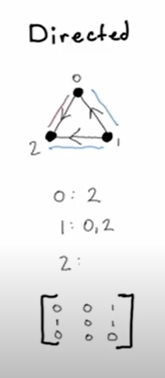

 ... which is exactly what we've expected.

In [86]:
Adj_Mat_di = adjacency_matrix(Digraph)
Adj_Mat_di

[[0, 0, 1], [1, 0, 1], [0, 0, 0]]

But, why are there multiple ways to represent a graph? 


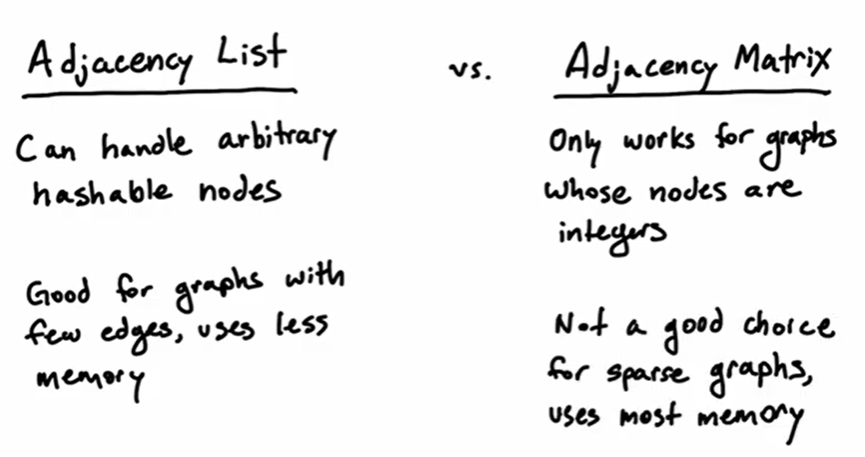